In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math
import cc3d

from mpl_toolkits.axes_grid1 import make_axes_locatable

t = 0

input_path = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS")
fname = "slab_entrainment_stats.nc"
file_path = input_path / fname

In [ ]:
ds_e = xr.open_dataset(file_path, group="Sum/Domain/Cloud")
ds_e["Total_net_E"].isel(time=t).z.values

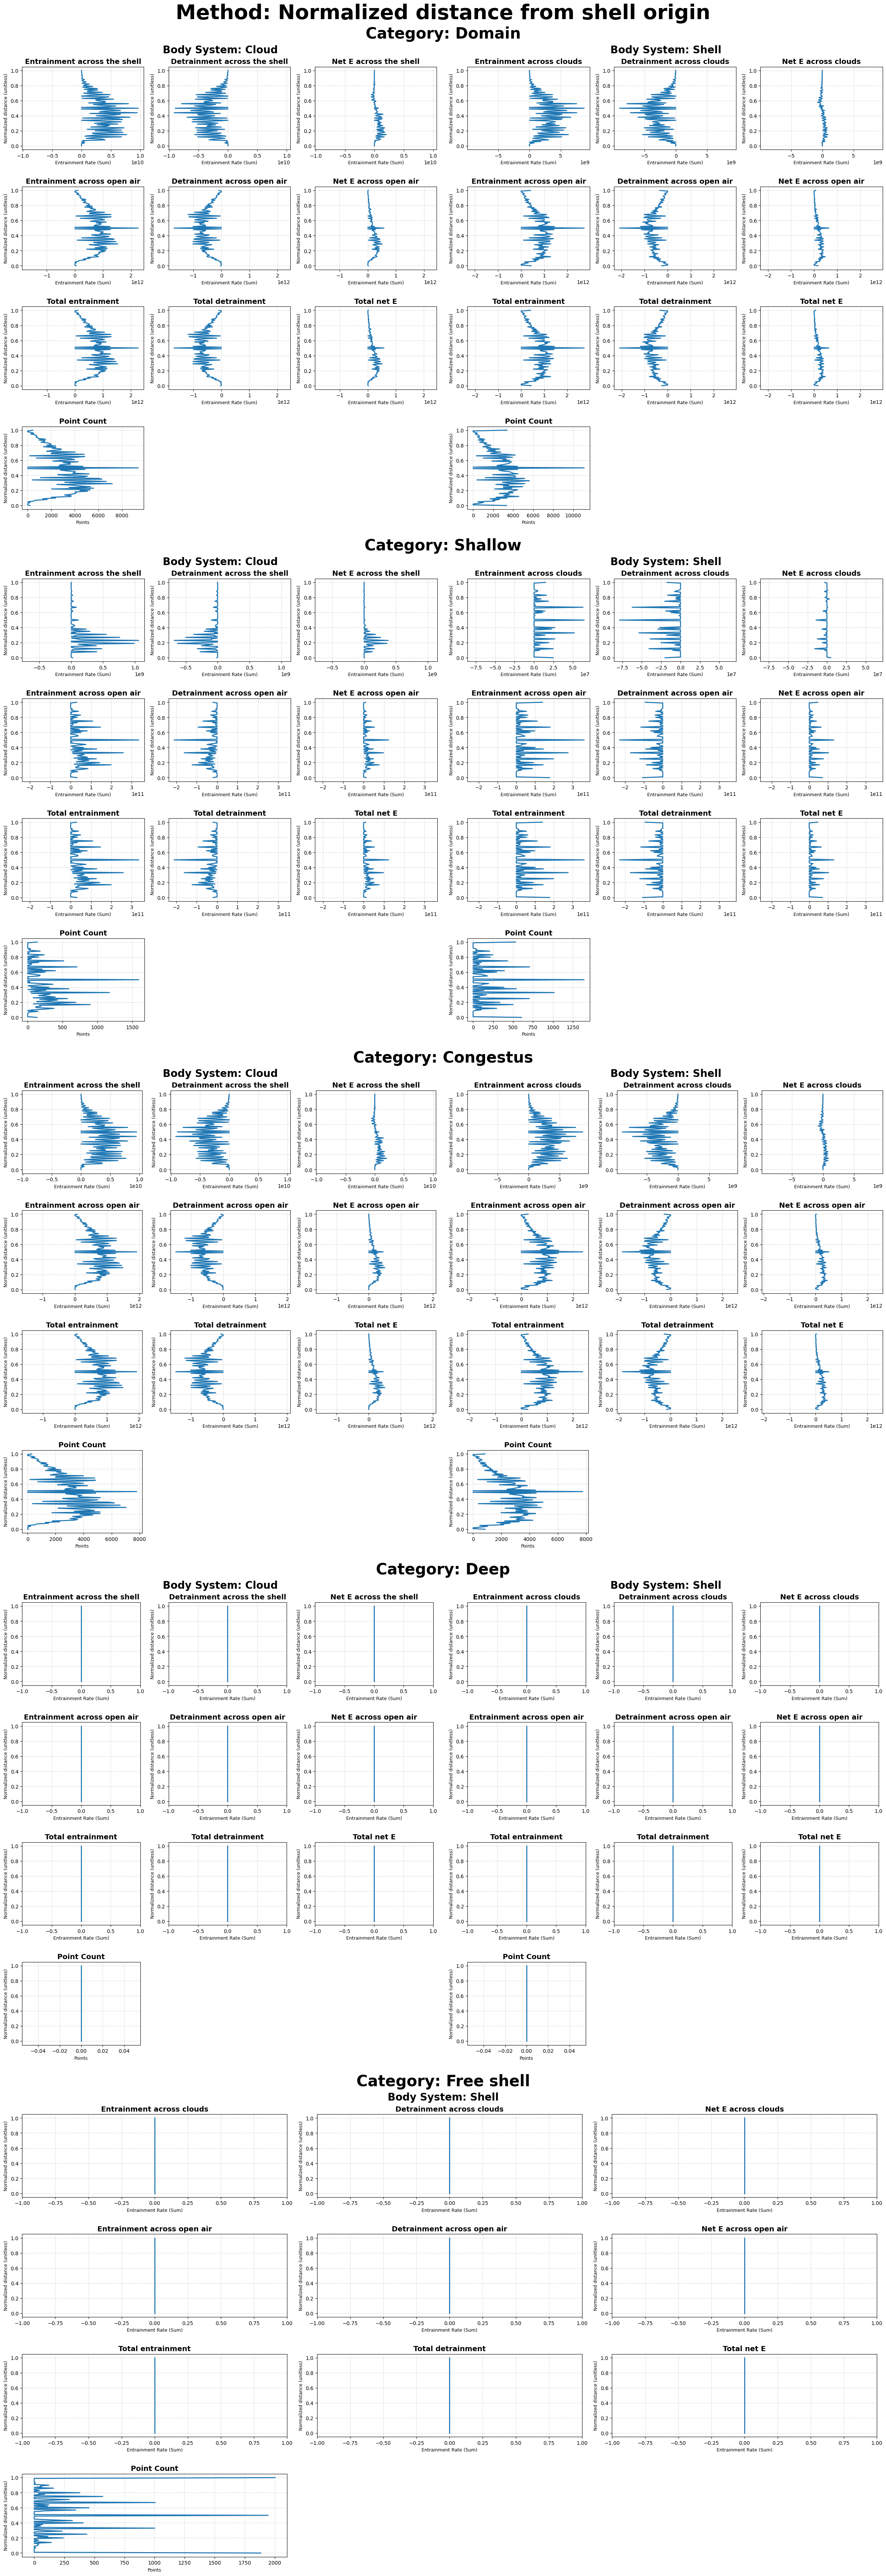

In [ ]:
# Plotting

BODY_GROUP_STRUCTURE = {
    "Normal": {
        "Cloud": ["Entrainment_across_the_shell", "Detrainment_across_the_shell", "Net_E_across_the_shell", 
                  "Entrainment_across_open_air", "Detrainment_across_open_air", "Net_E_across_open_air", 
                  "Total_entrainment", "Total_detrainment", "Total_net_E", "Point_Count"],
        "Shell": ["Entrainment_across_clouds", "Detrainment_across_clouds", "Net_E_across_clouds", 
                  "Entrainment_across_open_air", "Detrainment_across_open_air", "Net_E_across_open_air", 
                  "Total_entrainment", "Total_detrainment", "Total_net_E", "Point_Count"],
    },
    "Free_shell": {
        "Shell": ["Entrainment_across_clouds", "Detrainment_across_clouds", "Net_E_across_clouds", 
                  "Entrainment_across_open_air", "Detrainment_across_open_air", "Net_E_across_open_air", 
                  "Total_entrainment", "Total_detrainment", "Total_net_E", "Point_Count"],
    },
}

SUB_GROUP_STRUCTURE = {
    "Domain": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Shallow": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Congestus": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Deep": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Free_shell": BODY_GROUP_STRUCTURE["Free_shell"].copy()
}

GROUPS_STRUCTURE = {
    "Sum": SUB_GROUP_STRUCTURE.copy(),
    "Distance_from_shell_top": SUB_GROUP_STRUCTURE.copy(),
    "Distance_from_cloud_top": SUB_GROUP_STRUCTURE.copy(),
    "Normalized_distance_from_cloud_base": SUB_GROUP_STRUCTURE.copy(),
    "Normalized_distance_from_shell_origin": SUB_GROUP_STRUCTURE.copy()
}

COORD_MAP = {
    "Sum": "geom_z",
    "Distance_from_shell_top": "dist_shell_top",
    "Distance_from_cloud_top": "dist_cloud_top",
    "Normalized_distance_from_cloud_base": "norm_cloud_base",
    "Normalized_distance_from_shell_origin": "norm_shell_origin"
}


#group_array = ["Sum"]
#group_array = ["Distance_from_shell_top"]
#group_array = ["Distance_from_cloud_top"]
#group_array = ["Normalized_distance_from_cloud_base"]
group_array = ["Normalized_distance_from_shell_origin"]
#group_array = GROUPS_STRUCTURE.keys()


num_groups = len(group_array)


fig = plt.figure(figsize=(24, 70 * num_groups), layout='constrained')
if num_groups == 1:
    sb_groups = [fig.subfigures(nrows=1, ncols=1)]
else:
    sb_groups = fig.subfigures(nrows=num_groups, ncols=1)

i = 0
for top in group_array:
    num_categories = len(GROUPS_STRUCTURE[top])
    top_string = top.replace("_", " ")
    sb_groups[i].suptitle(f"Method: {top_string}", fontsize=40, weight='bold')
    sb_cats = sb_groups[i].subfigures(nrows=num_categories, ncols=1) # One subfigure per row
    
    # Handle single subfigure category edge case
    if num_categories == 1:
        sb_cats = [sb_cats]

    j = 0
    for mid, bodies in GROUPS_STRUCTURE[top].items():
        mid_string = mid.replace("_", " ")
        sb_cats[j].suptitle(f"Category: {mid_string}", fontsize=30, weight='bold')

        num_bodies = len(bodies)
        sb_body = sb_cats[j].subfigures(nrows=1, ncols=num_bodies)

        if num_bodies == 1:
            sb_body = [sb_body]

        k = 0
        for body, e_types in GROUPS_STRUCTURE[top][mid].items():
            body_string = body.replace("_", " ")
            sb_body[k].suptitle(f"Body System: {body_string}", fontsize=20, weight='bold')

            plot_cols = 3
            plot_rows = math.ceil(len(e_types) / plot_cols)
            
            
            global_x_min, global_x_max = 0.0, 0.0
            open_x_min, open_x_max = 0.0, 0.0
            interact_x_min, interact_x_max = 0.0, 0.0
            
            for e_type in e_types:
                if "Count" in e_type:
                    continue
                group_path = f"/{top}/{mid}/{body}/"
                try:
                    with xr.open_dataset(file_path, group=group_path) as ds:
                        vals = ds[e_type].isel(time=t).values
                        if "Total" in e_type:
                            global_x_min = min(global_x_min, np.nanmin(vals))
                            global_x_max = max(global_x_max, np.nanmax(vals))
                        elif "open" in e_type:
                            open_x_min = min(open_x_min, np.nanmin(vals))
                            open_x_max = max(open_x_max, np.nanmax(vals))
                        else:
                            interact_x_min = min(interact_x_min, np.nanmin(vals))
                            interact_x_max = max(interact_x_max, np.nanmax(vals))
                except Exception:
                    pass

            # Add a 5% visual padding buffer so lines don't hit the axis spine
            x_pad = (global_x_max - global_x_min) * 0.05 if global_x_max != global_x_min else 1.0
            global_x_max += x_pad
            global_x_min -= x_pad

            i_x_pad = (interact_x_max - interact_x_min) * 0.05 if interact_x_max != interact_x_min else 1.0
            interact_x_max += i_x_pad
            interact_x_min -= i_x_pad

            o_x_pad = (open_x_max - open_x_min) * 0.05 if open_x_max != open_x_min else 1.0
            open_x_max += o_x_pad
            open_x_min -= o_x_pad

            # Build axis grid matrix
            axes = sb_body[k].subplots(nrows=plot_rows, ncols=plot_cols)
            flat_axes = axes.flatten()
            L = 0
            for e_type in e_types:
                ax = flat_axes[L]

                group_path = f"/{top}/{mid}/{body}"
                e_type_label = e_type.replace("_", " ")

                try:
                    # 2. Open the specific group using xarray
                    with xr.open_dataset(file_path, group=group_path) as ds:
                        # Let's assume the variable is named 'entrainment' with dimensions (time, z)
                        # Slicing for the current timestep 't'
                        profile = ds[e_type].isel(time=t)
                        
                        
                        # 3. Plot the 1D profile (z-axis usually on the vertical y-axis)
                        
                        
                        # Aesthetics
                        if "Sum" in top:
                            profile.plot(
                                ax=ax, 
                                y="z", 
                                color='tab:blue', 
                                lw=2
                            )
                            ax.set_ylim(0, 6000)
                            ax.set_ylabel("Height z (m)", fontsize=9)
                        elif "Normalized" in top:
                            profile.plot(
                                ax=ax, 
                                y=f"exact_{COORD_MAP[top]}", 
                                color='tab:blue', 
                                lw=2
                            )
                            ax.set_ylabel("Normalized distance (unitless)", fontsize=9)
                            if "top" in top.lower():
                                ax.invert_yaxis()
                        else:
                            profile.plot(
                                ax=ax, 
                                y=f"exact_{COORD_MAP[top]}", 
                                color='tab:blue', 
                                lw=2
                            )
                            ax.set_ylabel("Distance (m)", fontsize=9)
                            if "top" in top.lower():
                                ax.invert_yaxis()

                        if "Count" not in e_type:
                            ax.set_xlabel("Entrainment Rate (Sum)", fontsize=9)
                            if "Total" in e_type:
                                ax.set_xlim(global_x_min, global_x_max)
                            elif "open" in e_type:
                                ax.set_xlim(open_x_min, open_x_max)
                            else:
                                ax.set_xlim(interact_x_min, interact_x_max)
                        else:
                            ax.set_xlabel("Points", fontsize=9)
                            
                            
                        ax.grid(True, linestyle="--", alpha=0.5)
                        
                except Exception as e:
                    # Handle cases where a specific group might be missing from the file
                    ax.text(0.5, 0.5, f"Group not found:\n{group_path}", 
                            ha='center', va='center', transform=ax.transAxes, color='red')
                    print(f"⚠️ Error opening group {group_path}: {e}")

                # open group and plot using xarray
                ax.set_title(f"{e_type_label}", fontsize=14, weight='bold')
                L += 1

            for empty_idx in range(L, len(flat_axes)):
                flat_axes[empty_idx].axis('off')

            k += 1

        j += 1

    i += 1

plt.show()

In [ ]:
ds_d = xr.open_dataset("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS/distance_from_shell_top.nc")
np.unique(ds_d.isel(time=t).distance.values)

array([   0.,   40.,   80.,  120.,  160.,  200.,  240.,  280.,  320.,
        360.,  400.,  440.,  480.,  520.,  560.,  600.,  640.,  680.,
        720.,  760.,  800.,  840.,  880.,  920.,  960., 1000., 1040.,
       1080., 1120., 1160., 1200., 1240., 1280., 1320., 1360., 1400.,
       1440.,   nan], dtype=float32)